## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [1]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___



k-평균을 사용할 때 클러스터 개수를 선택하는 간단한 방법은 엘보 규칙입니다. 클러스터 개수의 함수로 이너셔(각 샘플과 인접한 센트로이드 사이의 평균 제곱 거리)를 그리고 그래프에서 이너셔가 더는 빠르게 감소하지 않는 지점(엘보)를 찾습니다. 일반적으로 이 지점이 최적의 클러스터 개수에 가깝습니다. 다른 방법으로는 클러스터 개수의 함수로 실루엣 점수를 그래프로 그립니다. 그래프에 뾰족하게 올라간 지점이 나타나는 경우가 많은데 일반적으로 이 근처가 최적의 클러스터 개수입니다. 실루엣 점수는 모든 샘플에 대한 평균 실루엣 계수입니다. 샘플이 자신의 클러스터 안에 잘 속해 있고 다른 클러스터와 멀리 떨어져 있으면 +1에 가깝고 다른 클러스터에 매우 인접해 있으면 -1에 가까워집니다. 실루엣 다이어그램을 그려 좀 더 많은 분석을 수행할 수 있습니다.

### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___


k-평균과 BIRCH를 대규모 데이터셋에 적용할 수 있습니다. DBSCAN과 평균-이동이 밀도가 높은 지역을 찾습니다.

### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___


가우시안 혼합 모델(GMN)은 샘플이 파라미터를 모르는 몇 개의 가우시안 분포에서 생성되었다고 가정하는 확률 모델입니다. 다른 말로 하면 데이터가 유한한 개수의 타원 모양 클러스터로 그룹지어 있다는 가정입니다(클러스터의 타원 모양, 크기, 방향, 밀집도는 다를 수 있습니다). 하지만 샘플이 어떤 클러스터에 속해 있는지는 알지 못합니다. 밀집도 추정, 군집, 이상치 탐지에 이 모델을 사용할 수 있습니다.

### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.

#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [5]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

X = olivetti.data      # (400, 4096)
y = olivetti.target    # 사람 번호(0~39)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class 개수:", len(np.unique(y)))

X shape: (400, 4096)
y shape: (400,)
class 개수: 40


####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

# 1) train+valid / test 분할
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_valid_idx, test_idx in split1.split(X, y):
    X_train_valid = X[train_valid_idx]
    y_train_valid = y[train_valid_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]

# 2) train / valid 분할
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
# train_valid의 25%를 valid로 떼면 전체 기준 train:valid:test = 60:20:20

for train_idx, valid_idx in split2.split(X_train_valid, y_train_valid):
    X_train = X_train_valid[train_idx]
    y_train = y_train_valid[train_idx]
    X_valid = X_train_valid[valid_idx]
    y_valid = y_train_valid[valid_idx]

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape :", X_test.shape)

X_train shape: (240, 4096)
X_valid shape: (80, 4096)
X_test shape : (80, 4096)


####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

print("원본 차원:", X_train.shape[1])
print("축소 후 차원:", X_train_pca.shape[1])
print("설명된 분산 비율 합:", np.sum(pca.explained_variance_ratio_))

원본 차원: 4096
축소 후 차원: 176
설명된 분산 비율 합: 0.99008775


####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 21)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    valid_labels = kmeans.fit_predict(X_valid_pca)
    score = silhouette_score(X_valid_pca, valid_labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]
print("\n최적의 클러스터 개수 k:", best_k)

c:\Users\jk102\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jk102\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\jk102\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jk102\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


k=2, silhouette score=0.1675
k=3, silhouette score=0.1454
k=4, silhouette score=0.1239
k=5, silhouette score=0.1251
k=6, silhouette score=0.1202


c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

k=7, silhouette score=0.1177
k=8, silhouette score=0.1048
k=9, silhouette score=0.0966


c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=16, silhouette score=0.1332
k=17, silhouette score=0.1452
k=18, silhouette score=0.1587


c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=19, silhouette score=0.1568
k=20, silhouette score=0.1562

최적의 클러스터 개수 k: 2


c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


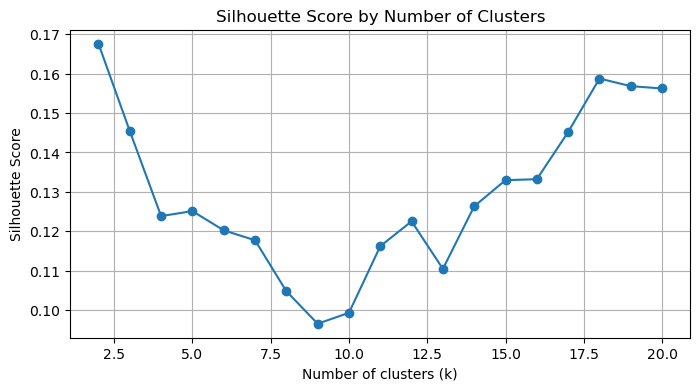

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid(True)
plt.show()

In [10]:
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_kmeans.fit(X_train_pca)

test_clusters = best_kmeans.predict(X_test_pca)

print("테스트 세트 클러스터 라벨:")
print(test_clusters[:20])

테스트 세트 클러스터 라벨:
[1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 1 0]


c:\Users\jk102\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [12]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()


[클러스터 0] 이미지 개수: 25


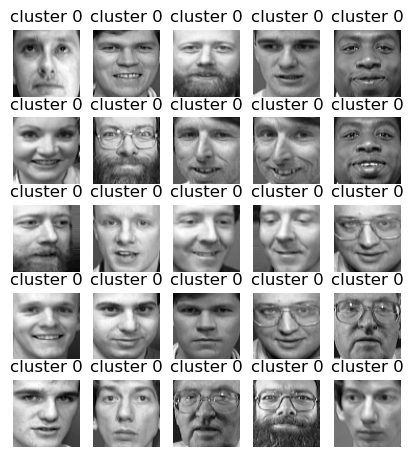


[클러스터 1] 이미지 개수: 55


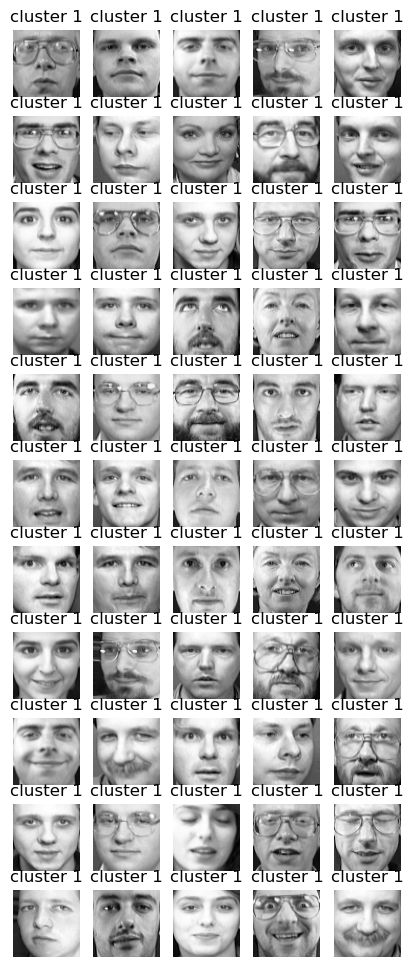

In [13]:
for cluster_id in range(best_k):
    cluster_idx = np.where(test_clusters == cluster_id)[0]
    cluster_faces = X_test[cluster_idx]
    cluster_labels = [f"cluster {cluster_id}" for _ in range(len(cluster_faces))]
    
    print(f"\n[클러스터 {cluster_id}] 이미지 개수: {len(cluster_faces)}")
    
    if len(cluster_faces) > 0:
        plot_faces(cluster_faces, cluster_labels, n_cols=5)